# Project 1 - Part 3: Data Analysis and Visualization
**Name:** Siddhant Shah  
**Date:** 3/7/2026  

## Purpose
The purpose of this notebook is to analyze student survey data and identify important factors influencing enrollment at CCM. Python Dictionaries and Sets were used to group data and create visualizations that will help the CCM IT Department improve its messaging to potential students.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# load the survey file
survey_data = pd.read_csv("cleaned_majors_survey_results.csv")

## Question 1
How do the most successful ways students heard about CCM differ in their effectiveness between recent high school graduates (18 and under) and older student age brackets (19+)?


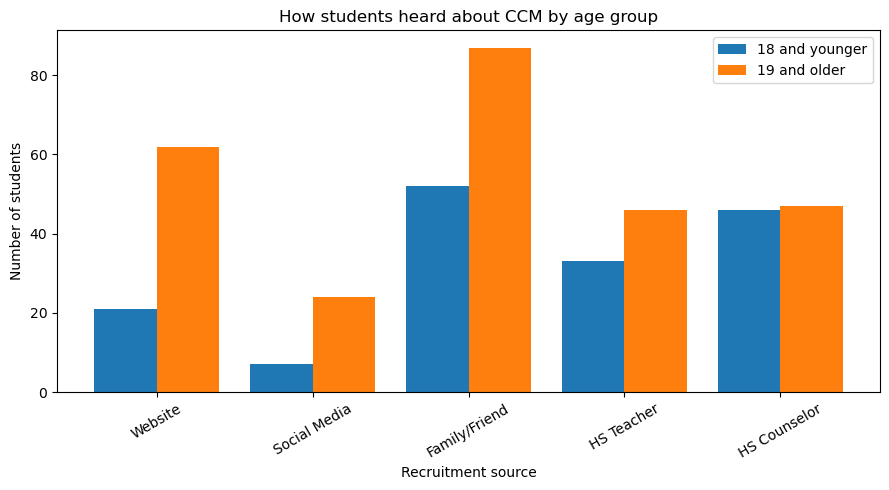

In [14]:
# recruitment sources from the survey
source_columns = [
    "heard_ccm_website",
    "heard_social_media",
    "heard_family_friend",
    "heard_hs_teacher",
    "heard_hs_counselor"
]

source_labels = [
    "Website",
    "Social Media",
    "Family/Friend",
    "HS Teacher",
    "HS Counselor"
]

# split students into the two age groups from the question
younger_students = survey_data[survey_data["age"] == "18 and younger"]
older_students = survey_data[survey_data["age"] != "18 and younger"]

younger_counts = []
older_counts = []

# count how many students in each age group answered yes
for column in source_columns:
    younger_total = (younger_students[column] == "Yes").sum()
    older_total = (older_students[column] == "Yes").sum()

    younger_counts.append(younger_total)
    older_counts.append(older_total)

# side-by-side bar chart
x_positions = list(range(len(source_labels)))
bar_width = 0.4

plt.figure(figsize=(9, 5))
plt.bar([x - bar_width / 2 for x in x_positions], younger_counts, width=bar_width, label="18 and younger")
plt.bar([x + bar_width / 2 for x in x_positions], older_counts, width=bar_width, label="19 and older")

plt.title("How students heard about CCM by age group")
plt.xlabel("Recruitment source")
plt.ylabel("Number of students")
plt.xticks(x_positions, source_labels, rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

## Findings
The data shows that family/friends and counselors are very effective for students aged 18 and under. However, older students are much more likely to hear about CCM through the website or family and friends.

## Question 2
Since the ability to transfer CCM credits to a 4-year school and affordable cost are a
significant driver of student enrollment to CCM, do these factors remain the strongest
drivers across all ethnic groups, or do different demographics prioritize other enrollment
factors?

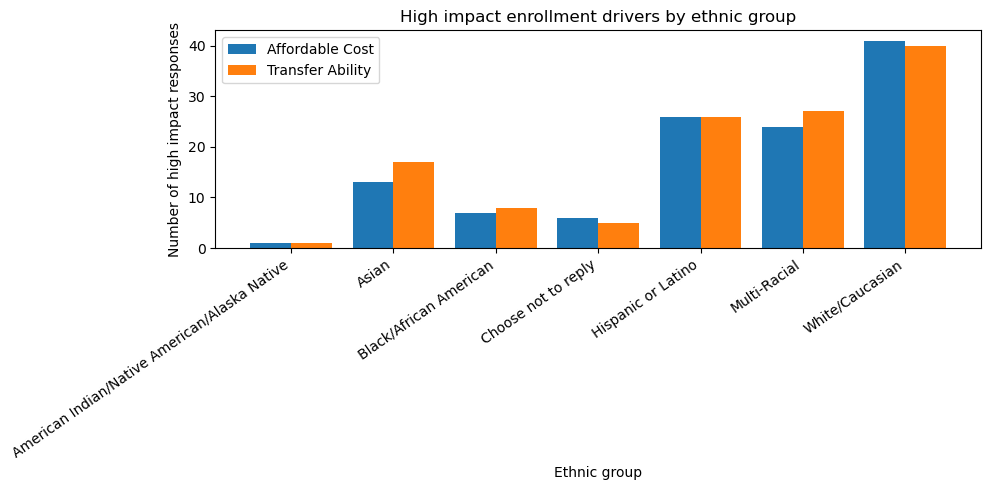

In [15]:
# get the ethnic groups that appear in the survey
ethnic_groups = sorted(survey_data["race_ethnicity"].dropna().unique())

cost_counts = []
transfer_counts = []

# count high impact responses for each group
for group in ethnic_groups:
    group_data = survey_data[survey_data["race_ethnicity"] == group]

    cost_total = (group_data["impact_affordable_cost"] == "High Impact").sum()
    transfer_total = (group_data["impact_transfer_ability"] == "High Impact").sum()

    cost_counts.append(cost_total)
    transfer_counts.append(transfer_total)

# make a bar chart
x_positions = list(range(len(ethnic_groups)))
bar_width = 0.4

plt.figure(figsize=(10, 5))
plt.bar([x - bar_width / 2 for x in x_positions], cost_counts, width=bar_width, label="Affordable Cost")
plt.bar([x + bar_width / 2 for x in x_positions], transfer_counts, width=bar_width, label="Transfer Ability")

plt.title("High impact enrollment drivers by ethnic group")
plt.xlabel("Ethnic group")
plt.ylabel("Number of high impact responses")
plt.xticks(x_positions, ethnic_groups, rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Findings:
Affordable cost and the ability to transfer credits remain consistently high across most ethnic groups. However, some groups, such as Multi-Racial students, show a slightly higher preference for cost over transfer ability.

## Question 3
Among the pre-college events with the highest participation in the survey, which specific
events had the highest proportion of enrolled female or minority students?

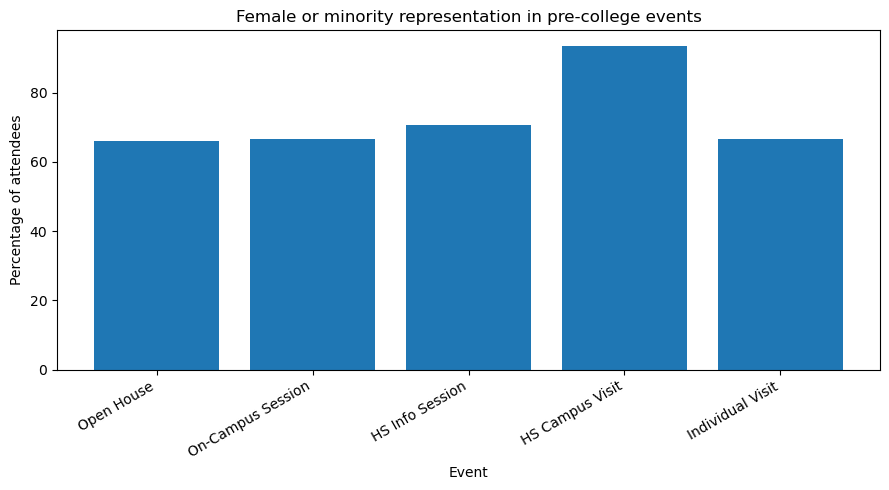

In [16]:
# minority groups used for this question
minority_groups = {
    "Hispanic or Latino",
    "Asian",
    "Black/African American",
    "Multi-Racial",
    "American Indian/Native American/Alaska Native"
}

# event columns with nice labels for the graph
event_columns = [
    "event_open_house",
    "event_on_campus_session",
    "event_hs_info_session",
    "event_hs_campus_visit",
    "event_individual_campus_visit"
]

event_labels = [
    "Open House",
    "On-Campus Session",
    "HS Info Session",
    "HS Campus Visit",
    "Individual Visit"
]

event_percentages = []

# find the percentage of attendees who were female or minority students
for column in event_columns:
    event_data = survey_data[survey_data[column] == "Yes"]
    total_attended = len(event_data)

    match_count = 0

    for _, row in event_data.iterrows():
        is_female = row["gender"] == "Woman"
        is_minority = row["race_ethnicity"] in minority_groups

        if is_female or is_minority:
            match_count += 1

    if total_attended > 0:
        percent = (match_count / total_attended) * 100
    else:
        percent = 0

    event_percentages.append(percent)

# make a bar chart
plt.figure(figsize=(9, 5))
plt.bar(event_labels, event_percentages)
plt.title("Female or minority representation in pre-college events")
plt.xlabel("Event")
plt.ylabel("Percentage of attendees")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Findings:
High school information sessions and high school campus visits show a high proportion of diverse students. On campus sessions also effectively reach a significant percentage of minority and female students.

## Question 4:
To what extent does prior exposure to the computing field (such as previous coursework
or personal connections) impact the decision to enroll for female students compared to
male students, and would a potential lack of early exposure pose a barrier to recruiting
women?


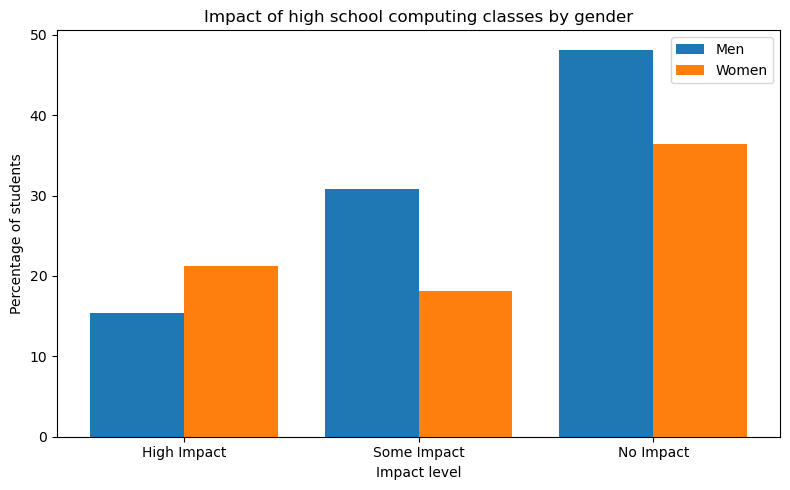

In [17]:
# compare men and women on the impact of high school computing classes
male_students = survey_data[survey_data["gender"] == "Man"]
female_students = survey_data[survey_data["gender"] == "Woman"]

impact_levels = ["High Impact", "Some Impact", "No Impact"]

male_percentages = []
female_percentages = []

total_males = len(male_students)
total_females = len(female_students)

for level in impact_levels:
    male_count = (male_students["computing_hs_class"] == level).sum()
    female_count = (female_students["computing_hs_class"] == level).sum()

    male_percent = (male_count / total_males) * 100
    female_percent = (female_count / total_females) * 100

    male_percentages.append(male_percent)
    female_percentages.append(female_percent)

# make bar chart
x_positions = list(range(len(impact_levels)))
bar_width = 0.4

plt.figure(figsize=(8, 5))
plt.bar([x - bar_width / 2 for x in x_positions], male_percentages, width=bar_width, label="Men")
plt.bar([x + bar_width / 2 for x in x_positions], female_percentages, width=bar_width, label="Women")

plt.title("Impact of high school computing classes by gender")
plt.xlabel("Impact level")
plt.ylabel("Percentage of students")
plt.xticks(x_positions, impact_levels)
plt.legend()
plt.tight_layout()
plt.show()

## Findings:
A higher number of women report that high school computing classes had a "High Impact" on their decision to enroll. For men, while some report high impact, a larger proportion falls into the "Some Impact" or "No Impact" categories. This suggests that strengthening early exposure is moderately important in recruiting more women into computing.